In [27]:
from typing import Any, Callable

import equinox as eqx
import jax
import jax.numpy as jnp
from spyx.axn import arctan

_spike_fn = arctan(k=2)


class FeLIF(eqx.Module):
    out_size: int = eqx.field(static=True)
    P_s: float = eqx.field(static=True)  # max polarisation
    A: float = eqx.field(static=True)
    C_tot: float = eqx.field(static=True)
    threshold: float = eqx.field(static=True)
    step: Callable[[Any, Any], Any] = eqx.field(static=True)
    updatePol: Callable[[Any, Any], Any] = eqx.field(static=True)
    cap_divider: float = eqx.field(static=True)
    depol_divider: float = eqx.field(static=True)

    def __init__(
        self,
        out_size,
        A=25e-12,  # device area
        t_hzo=10e-9,  # thikness ferroelectric
        t_int=1.375e-9,  # thikness interlayer
        eps_hzo=25.2,  # ferroelectric dielectric constant
        eps_int=33,  # interlayer dielectric constant
        E_a=12.7e8,  # coercitive field
        P_s=22e-2,  # max polarisation
        tau_0=1e-13,  # multiplicative factor for switching time constant
        I_0=1e-4,  # mult factor for leakage current
        V_t=0.32,  # normalization factor for voltage in leakage current
        C_par=15e-15,  # parasitic capacitance form the circuit
        alpha=1.3,  # to fit tau exponential
        soft_E=5e6,  # soft boudary for the electric field, avoid tau to diverge
        I_dsc=10e-12,  # discharge current, set the "dendritic time constant"
        V_thr=2.5,
        dt=1e-3,  # 1us timestep resolution
        innerStep=1000,
        paramsScale=1e12,  # Scale parameters to avoid underflow
        spike_fn=_spike_fn,
        stepFull=False,
        *,
        key=None
    ):
        _eps0 = 8.85418792394420013968e-12 * paramsScale
        self.out_size = out_size

        A = A * paramsScale
        self.A = A
        t_hzo = t_hzo * paramsScale
        t_int = t_int * paramsScale
        eps_hzo = eps_hzo
        eps_int = eps_int
        E_a = E_a / paramsScale
        P_s = P_s
        tau_0 = tau_0
        I_0 = I_0
        V_t = V_t
        C_par = C_par * paramsScale
        alpha = alpha
        soft_E = soft_E / paramsScale
        I_dsc = I_dsc * paramsScale
        V_thr = V_thr
        dt = dt
        innerStep = innerStep
        paramsScale = paramsScale

        C_0 = _eps0 * eps_hzo / t_hzo * A
        C_tot = C_0 + C_par
        self.C_tot = C_tot

        cap_divider = eps_int / (t_hzo * eps_hzo + t_int * eps_int)
        self.cap_divider = cap_divider
        depol_divider = 1 / _eps0 * t_int / (t_hzo * eps_hzo + t_int * eps_int)
        self.depol_divider = depol_divider
        threshold = V_thr * C_tot + P_s * A
        self.threshold = threshold
        self.P_s = P_s

        @jax.custom_vjp
        def tau_fn(E):
            tau = tau_0 * jnp.exp((E_a / (jnp.abs(E) + 5e-6)) ** alpha)

            return tau

        def tau_fn_fwd(E):
            return tau_fn(E), (E,)

        def tau_fn_bw(res, g):
            (E,) = res
            exp_x = jnp.clip((E_a / (jnp.abs(E) + soft_E)) ** alpha, 0, 1)
            tau_prime = -(
                tau_0
                * E_a
                * alpha
                * E
                * jnp.exp(exp_x)
                * (E_a / (jnp.abs(E) + soft_E)) ** (alpha - 1)
            ) / (jnp.abs(E) * (E + soft_E) ** 2)

            tangents_out = (g * tau_prime,)
            return tangents_out

        tau_fn.defvjp(tau_fn_fwd, tau_fn_bw)

        def updatePol(v, p):

            def pol_step(state, input_):
                p, _ = state
                E = v * cap_divider - p * depol_divider

                tau = tau_0 * jnp.exp((E_a / (jnp.abs(E) + 5e-6)) ** alpha)

                I_p_new = (jnp.sign(E) * P_s - p) * A / tau
                dp = I_p_new / A
                p = jnp.clip(p + 1e-3 * dt * dp, -P_s, P_s)
                return (p, I_p_new), None

            def pol_step2(p):
                E = v * cap_divider - p * depol_divider

                tau = tau_fn(E)

                I_p_new = (jnp.sign(E) * P_s - p) * A / jax.lax.stop_gradient(tau)
                dp = I_p_new / A
                p = jnp.clip(p + dt * dp, -P_s, P_s)
                return p, I_p_new

            (p_inner, I_p_inner), _ = jax.lax.scan(
                pol_step, (p, jnp.zeros_like(p)), jnp.arange(1000)
            )

            p_outer, I_p_outer = pol_step2(p)

            p = p_outer + jax.lax.stop_gradient(p_inner - p_outer)
            I_p = I_p_outer + jax.lax.stop_gradient(I_p_inner - I_p_outer)

            return p, I_p

        self.updatePol = updatePol

        def step(state, input_):
            v, p = state

            # charge = v * C_tot + p * A
            spikes = spike_fn(v - V_thr)

            p_upper, I_p = updatePol(v, p)

            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - jax.lax.stop_gradient(I_p)) / C_tot

            v_upper = jnp.clip(v + dt * dv, -5, 5)

            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new), (v_new, p_new, spikes)

        def step_full(state, input_):
            v, p = state

            # charge = v * C_tot + p * A
            spikes = spike_fn(v - V_thr)

            E = v * self.cap_divider - p * self.depol_divider

            tau = tau_0 * jnp.exp((E_a / (jnp.abs(E) + 5e-6)) ** alpha)

            I_p = (jnp.sign(E) * self.P_s - p) * A / tau
            dp = I_p / A

            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot

            v_upper = jnp.clip(v + dt * dv, -5, 5)
            p_upper = jnp.clip(p + dt * dp, -self.P_s, self.P_s)

            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new), (v_new, p_new, spikes)

        if stepFull:
            self.step = jax.jit(step_full)
        else:
            self.step = jax.jit(step)

    @eqx.filter_jit
    def getCharge(self, v, p):
        return v * self.C_tot + p * self.A

    @jax.named_scope("nn.FeLIF")
    def __call__(self, input_):
        v0 = jnp.zeros((self.out_size,))
        p0 = jnp.zeros((self.out_size,)) - self.P_s

        state = (v0, p0)
        _, out = jax.lax.scan(self.step, state, input_)
        v, p, s = out

        return s, self.getCharge(v, p), v, p

Polarization inner loop gradient analysis

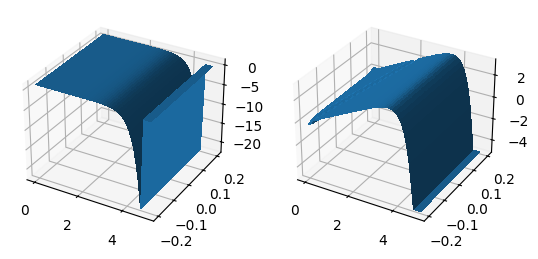

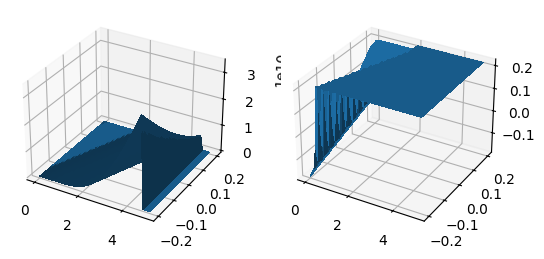

In [29]:
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-3, stepFull=False, key=None)


def test(v, p, input_):
    # charge = v * C_tot + p * A
    p_upper, I_p = felif.updatePol(v, p)
    I_leak = (1e-4 * felif.A * jnp.expm1(v / 0.32) + 10) * jnp.sign(v)
    dv = (input_ - I_leak - I_p) / felif.C_tot
    v_upper = jnp.clip(v + 1e-3 * dv, -5, 5)

    return v_upper, p_upper


test_grad = jax.value_and_grad(test, argnums=(0, 1, 2), has_aux=True)

voltages = jnp.linspace(0, 5)
polarization = jnp.linspace(-0.2, 0.2)
input_ = jnp.ones((50, 50))
X, Y = jnp.meshgrid(voltages, polarization)
values, gradients = jax.vmap(test_grad)(X.ravel(), Y.ravel(), input_.ravel())

fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
ax[0].plot_surface(X, Y, gradients[0].reshape(50, 50), linewidth=0, antialiased=False)
ax[1].plot_surface(X, Y, values[0].reshape(50, 50), linewidth=0, antialiased=False)

fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
ax[0].plot_surface(X, Y, gradients[1].reshape(50, 50), linewidth=0, antialiased=False)
ax[1].plot_surface(X, Y, values[1].reshape(50, 50), linewidth=0, antialiased=False)
plt.show()

Comparison

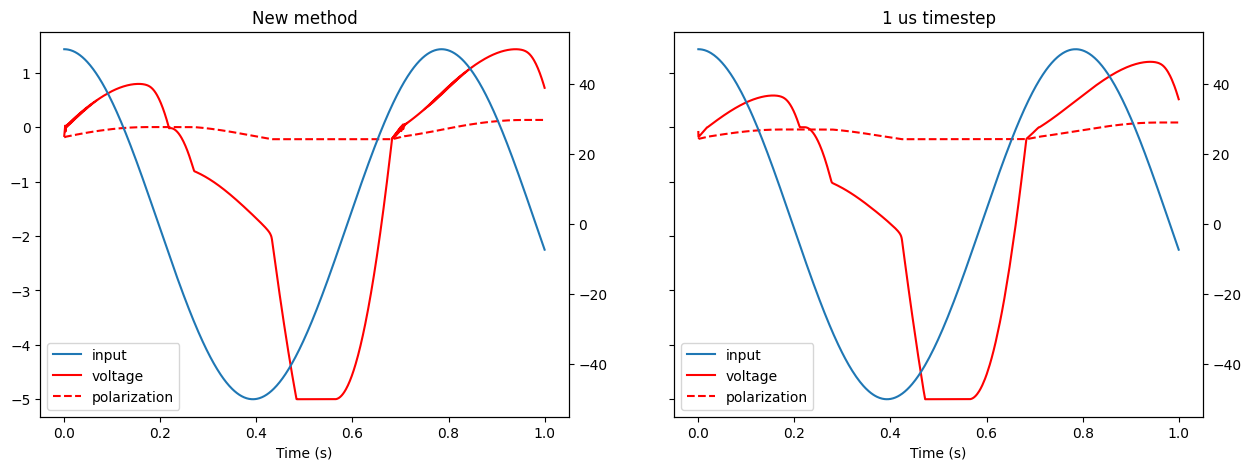

In [30]:
import matplotlib.pyplot as plt

t = jnp.linspace(0, 1, 1000)
input = 1.0 * 50 * jnp.cos(8 * t)
# input = 1.0 * 50 * jnp.sign(input) * (jnp.abs(input) > 0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-3, stepFull=False, key=None)
s, c, v, p = felif(input)

t_us = jnp.linspace(0, 1, 1000000)
input_us = 1.0 * 50 * jnp.cos(8 * t_us)
# input_us = 1.0 * 50 * jnp.sign(input_us) * (jnp.abs(input_us) > 0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-6, stepFull=True, key=None)
s_us, c_us, v_us, p_us = felif(input_us)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax = axs[0].twinx()
lns1 = ax.plot(t, input, label="input")
lns2 = axs[0].plot(t, v, "r", label="voltage")
lns3 = axs[0].plot(t, p, "r--", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[0].set_xlabel("Time (s)")
axs[0].set_title("New method")

ax = axs[1].twinx()
lns1 = ax.plot(t_us, input_us, label="input")
lns2 = axs[1].plot(t_us, v_us, "r", label="voltage")
lns3 = axs[1].plot(t_us, p_us, "r--", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[1].set_xlabel("Time (s)")
axs[1].set_title("1 us timestep")

plt.savefig("polloop.png")

Training example

In [31]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import matplotlib.pyplot as plt
import optax
from spyx.axn import superspike
from spyx.loaders import SHD_loader

In [32]:
_spike_fn = superspike(k=100)


class CUBALIF(eqx.Module):
    hidden_size: int = eqx.field(static=True)
    alpha: float = eqx.field(static=True)
    beta: float = eqx.field(static=True)

    def __init__(self, hidden_size, alpha, beta, *, key=None):
        self.hidden_size = hidden_size
        self.alpha = alpha
        self.beta = beta

    def __call__(self, input_):
        hidden = (jnp.zeros((self.hidden_size,)), jnp.zeros((self.hidden_size,)))

        def f(carry, inp):
            syn, mem = carry

            mtr = mem - 1.0
            out = _spike_fn(mtr)
            rst = jax.lax.stop_gradient(out)

            new_syn = self.alpha * syn + inp
            new_mem = (self.beta * mem) * (1.0 - rst) + new_syn

            return (new_syn, new_mem), out

        _, out = jax.lax.scan(f, hidden, input_)

        return out


class Network(eqx.Module):
    layer1: CUBALIF
    linear1: eqx.nn.Linear

    layer2: FeLIF
    linear2: eqx.nn.Linear

    def __init__(self, in_size, hidden_size, out_size, alpha, beta, *, key):
        key1, key2 = jax.random.split(key, 2)
        self.layer1 = CUBALIF(hidden_size, alpha, beta)
        self.linear1 = eqx.nn.Linear(in_size, hidden_size, use_bias=False, key=key1)

        self.layer2 = FeLIF(
            out_size, spike_fn=_spike_fn, dt=1e-3, stepFull=False, key=None
        )
        self.linear2 = eqx.nn.Linear(hidden_size, out_size, key=key2)

        # get_weights = lambda m: m.weight
        # new_weights = linear2.weight*1000
        # self.linear2 = eqx.tree_at(get_weights, linear2, new_weights)

    def __call__(self, input_):
        x1 = jax.vmap(self.linear1)(input_)
        s1 = self.layer1(x1)

        x2 = jax.vmap(self.linear2)(s1 * 1000)
        s2, charge, v2, _ = self.layer2(x2)

        return s2, (s1, charge)

In [33]:
batch_size = 128
nb_epochs = 200
nb_steps = 72
nb_inputs = 700
nb_hidden = 200
nb_outputs = 20
learning_rate = 2e-4
time_step = 14e-3

tau_mem = 1680e-3
tau_syn = 5e-3

alpha = 0  # jnp.exp(-time_step/tau_syn)
beta = jnp.exp(-time_step / tau_mem)
shd_dl = SHD_loader(batch_size, nb_steps, nb_inputs, 0.2)

In [81]:
@jax.jit
def accuracy_fn(output, y):
    predicted_class = jnp.argmax(jnp.sum(output, axis=1), axis=1)
    return jnp.mean(predicted_class == y)


@eqx.filter_value_and_grad
def compute_loss(model, x, y):
    pred_y, (spks, _) = jax.vmap(model)(x)

    # reg_loss1 = 2e-6 * jnp.sum(spks)  # L1 loss on total number of spikes
    # reg_loss2 = 2e-6 * jnp.mean(
    #     jnp.sum(spks, axis=1) ** 2
    # )  # L2 loss on spikes per neuron

    # reg_loss1 = 2e-6*jnp.mean(jnp.abs(jnp.sum(spks,axis=1).ravel()-4.0))
    # reg_loss2 = 2e-6*jnp.mean((jnp.sum(spks,axis=1).ravel()-4.0)**2)
    reg_loss1 = 2e-2 * jnp.mean(jax.nn.relu(20 - jnp.sum(pred_y, axis=(1, 2))) ** 2)

    m = jnp.max(pred_y, axis=1)  # Sum over time
    # Here we combine supervised loss and the regularizer
    loss_val = (
        optax.softmax_cross_entropy(m, jax.nn.one_hot(y, nb_outputs)).mean()
        + reg_loss1
        # + reg_loss2
    )

    return loss_val

In [82]:
@eqx.filter_jit
def make_step(model, x, y, opt_state):
    loss, grads = compute_loss(model, x, y)

    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


@eqx.filter_jit
def epoch_step(state, data):
    model, opt_state = state
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    loss, model, opt_state = make_step(model, x, y, opt_state)

    return (model, opt_state), loss


@eqx.filter_jit
def test_step(model, data):
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    pred_y, (_, _) = jax.vmap(model)(x)

    return model, accuracy_fn(pred_y, y)

In [83]:
rngkey = jax.random.key(0)
model = Network(nb_inputs, nb_hidden, nb_outputs, alpha, beta, key=rngkey)
optim = optax.adamax(learning_rate, b1=0.9, b2=0.999)
opt_state = optim.init(model)

In [84]:
model.linear2.weight

Array([[-0.01231346,  0.00300242,  0.01090152, ...,  0.01837822,
         0.06714929,  0.03170027],
       [-0.05593233,  0.05691364,  0.06427521, ..., -0.03860701,
        -0.03943951, -0.03864204],
       [-0.00368866,  0.05156777, -0.03092544, ..., -0.06592533,
         0.05609231,  0.03801405],
       ...,
       [-0.00846135,  0.02489024, -0.00022314, ...,  0.02001701,
         0.04352178, -0.02822075],
       [-0.06700739,  0.05588741, -0.02754838, ...,  0.03914492,
         0.04084534,  0.04525085],
       [ 0.00501586,  0.0039251 ,  0.06338368, ...,  0.0624954 ,
         0.03734253, -0.00853187]], dtype=float32)

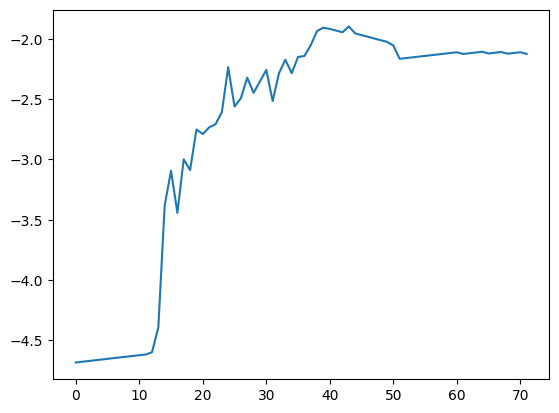

In [88]:
x_test, y_test = shd_dl.test_epoch()
x = jnp.unpackbits(x_test[0], axis=1)
pred_y, (s1, charge) = jax.vmap(model)(x)

plt.figure()
plt.plot(charge[0, :, 4])
plt.show()

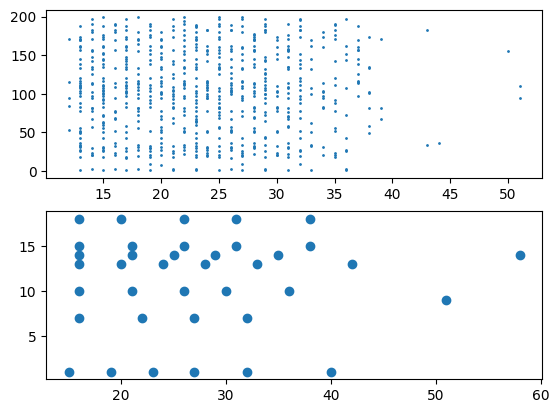

In [90]:
_, axs = plt.subplots(2, 1)
axs[0].scatter(*jnp.where(s1[0]), s=1)
axs[1].scatter(*jnp.where(pred_y[0]))
plt.show()

Epoch 1: loss=3.36675 accuracy=0.05009
Epoch 2: loss=3.11204 accuracy=0.05377
Epoch 3: loss=3.09136 accuracy=0.05882
Epoch 4: loss=3.07991 accuracy=0.05285
Epoch 5: loss=3.06889 accuracy=0.04825


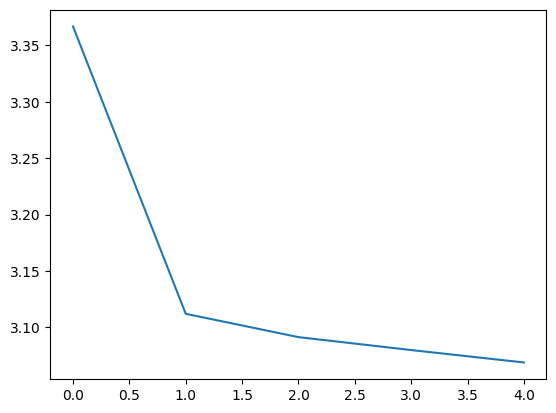

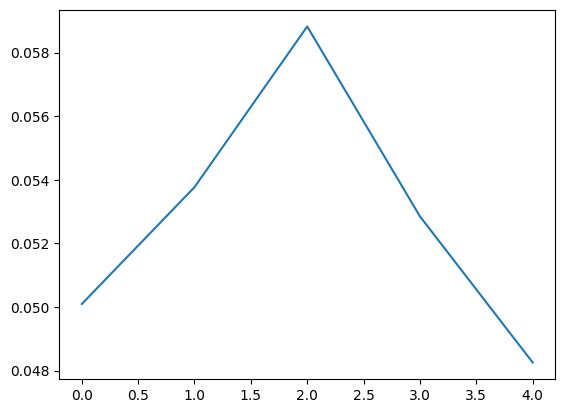

In [87]:
total_loss = []
total_accuracy = []

for epoch in range(5):
    epoch_key = jax.random.fold_in(rngkey, nb_epochs)
    x_train, y_train = shd_dl.train_epoch(epoch_key)
    (model, opt_state), loss = jax.lax.scan(
        epoch_step, (model, opt_state), (x_train, y_train)
    )

    x_test, y_test = shd_dl.test_epoch()
    _, accuracy = jax.lax.scan(test_step, model, (x_test, y_test))

    total_loss.append(jnp.mean(loss).item())
    total_accuracy.append(jnp.mean(accuracy).item())
    print(
        "Epoch %i: loss=%.5f accuracy=%.5f"
        % (epoch + 1, jnp.mean(loss), jnp.mean(accuracy))
    )

    # if epoch % 10 == 0:
    #     # eqx.tree_serialise_leaves("shd.eqx", model)
    #     plt.figure()
    #     plt.plot(total_loss)
    #     plt.savefig("loss_polloop.png")

    #     plt.figure()
    #     plt.plot(total_accuracy)
    #     plt.savefig("accuracy_polloop.png")

plt.figure()
plt.plot(total_loss)
plt.savefig("loss_polloop.png")

plt.figure()
plt.plot(total_accuracy)
plt.savefig("accuracy_polloop.png")